In [1]:
pip install pandas matplotlib seaborn numpy


Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define file paths
file_paths = {
    "gpt-3.5-turbo": "/Users/dilanka/Downloads/reasoning evaluation/data/gpt-3.5-turbo.csv",
    "gpt-4-turbo": "/Users/dilanka/Downloads/reasoning evaluation/data/gpt-4-turbo.csv",
    "allam-2-7b": "/Users/dilanka/Downloads/reasoning evaluation/data/allam-2-7b.csv",
    "llama-3.3-70b-versatile": "/Users/dilanka/Downloads/reasoning evaluation/data/llama-3.3-70b-versatile.csv",
    "deepseek-r1-distill-llama-70b": "/Users/dilanka/Downloads/reasoning evaluation/data/deepseek-r1-distill-llama-70b.csv"
}

# Load the data
evaluation_data = {}
for model, path in file_paths.items():
    evaluation_data[model] = pd.read_csv(path)

# Preview a sample dataset
for model, df in evaluation_data.items():
    print(f"📌 Sample Data from {model}:\n", df.head(), "\n")
    break  # Print only one model's data for preview


📌 Sample Data from gpt-3.5-turbo:
    index                                               text  \
0      0  in the end we all die, nothing we do means any...   
1      1  Today would have been my best friend's 18th bi...   
2      2  So I couldn't feel any worse, and I've had eno...   
3      3  I am 22 and have never had a girlfriend and ha...   
4      4  I am almost certain that my depression is caus...   

                                     original_reason  \
0  feel more and more empty,fear lonliness,get ti...   
1   best friend's birthday, he's gone, never supp...   
2  absolute minimal contact with,  be more direct...   
3   never had a girlfriend, rejected countless times   
4  eating out with family, what after that? Paren...   

                                    generated_reason  original_reason_score  \
0  The person seems to be experiencing alienation...                     85   
1  The emotional distress, grief, and longing exp...                     90   
2  The perso

# Histogram of Original vs. Generated Scores

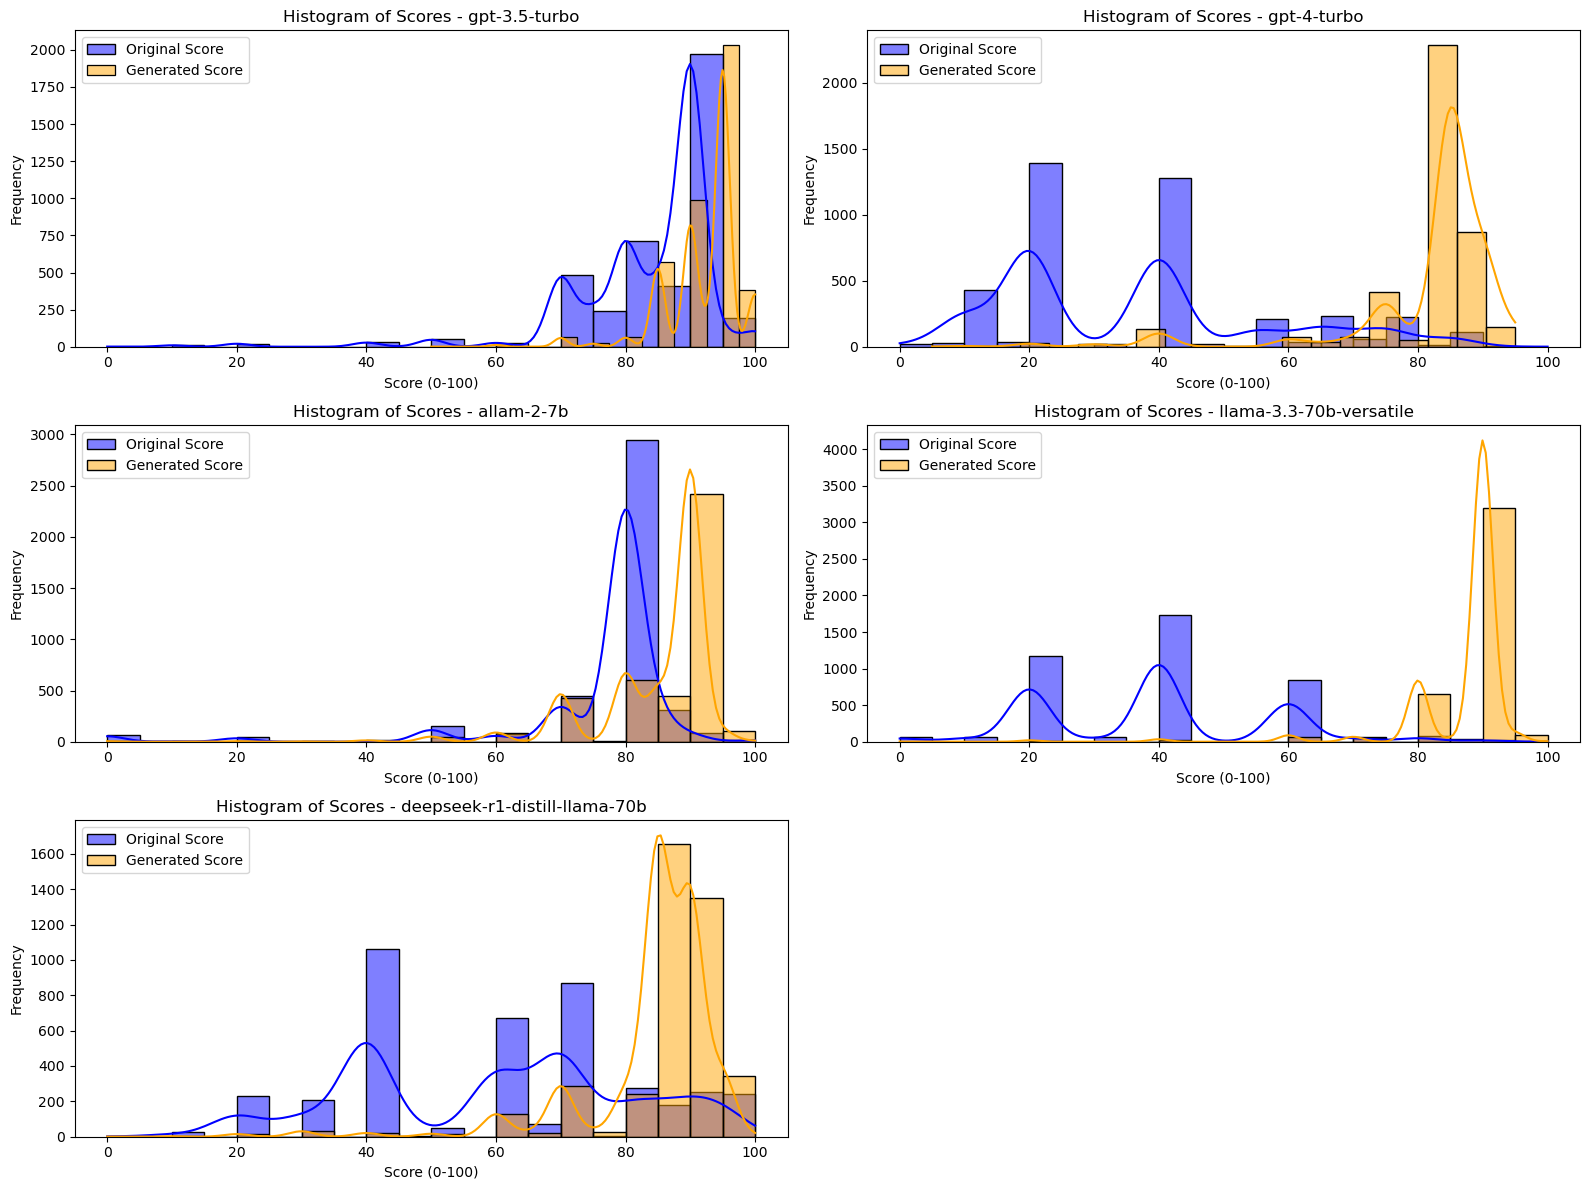

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define figure size
plt.figure(figsize=(16, 12))

# Loop through each model and create individual histograms
for i, (model, df) in enumerate(evaluation_data.items(), 1):
    plt.subplot(3, 2, i)  # Create a 3-row, 2-column subplot layout
    sns.histplot(df["original_reason_score"], kde=True, label="Original Score", bins=20, alpha=0.5, color="blue")
    sns.histplot(df["generated_reason_score"], kde=True, label="Generated Score", bins=20, alpha=0.5, color="orange")
    
    plt.xlabel("Score (0-100)")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Scores - {model}")
    plt.legend()

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()


# Boxplot of Original vs. Generated Scores

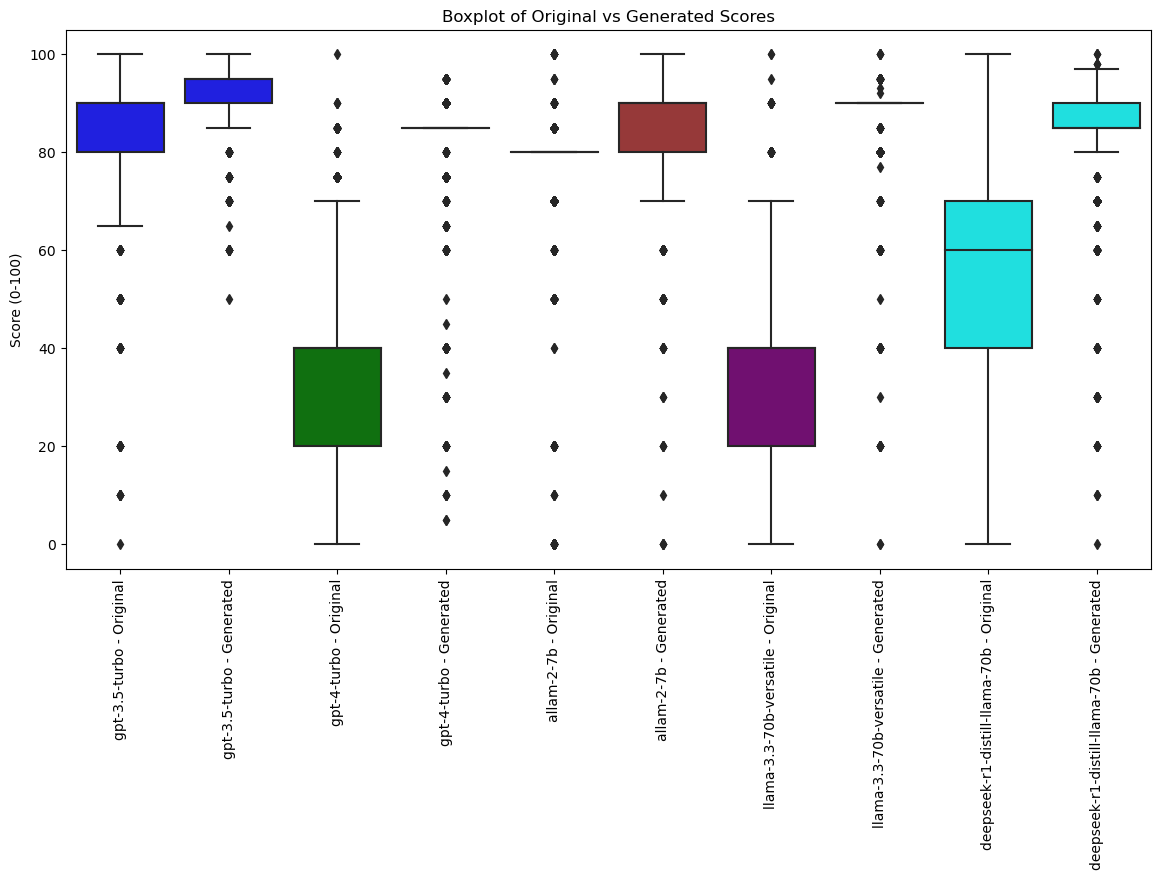

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define color palette: One color per model
model_colors = {
    "gpt-3.5-turbo": "blue",
    "gpt-4-turbo": "green",
    "allam-2-7b": "brown",
    "llama-3.3-70b-versatile": "purple",
    "deepseek-r1-distill-llama-70b": "cyan"
}

plt.figure(figsize=(14, 7))

# Prepare data and labels
data = []
labels = []
palette = []  # Store colors for better visualization

for model, df in evaluation_data.items():
    data.append(df["original_reason_score"])
    labels.append(f"{model} - Original")
    palette.append(model_colors[model])  # Assign color

    data.append(df["generated_reason_score"])
    labels.append(f"{model} - Generated")
    palette.append(model_colors[model])  # Keep the same color

# Create the boxplot with assigned colors
sns.boxplot(data=data, palette=palette)

plt.xticks(range(len(labels)), labels, rotation=90)
plt.ylabel("Score (0-100)")
plt.title("Boxplot of Original vs Generated Scores")

plt.show()


# Violin Plot for Score Distributions

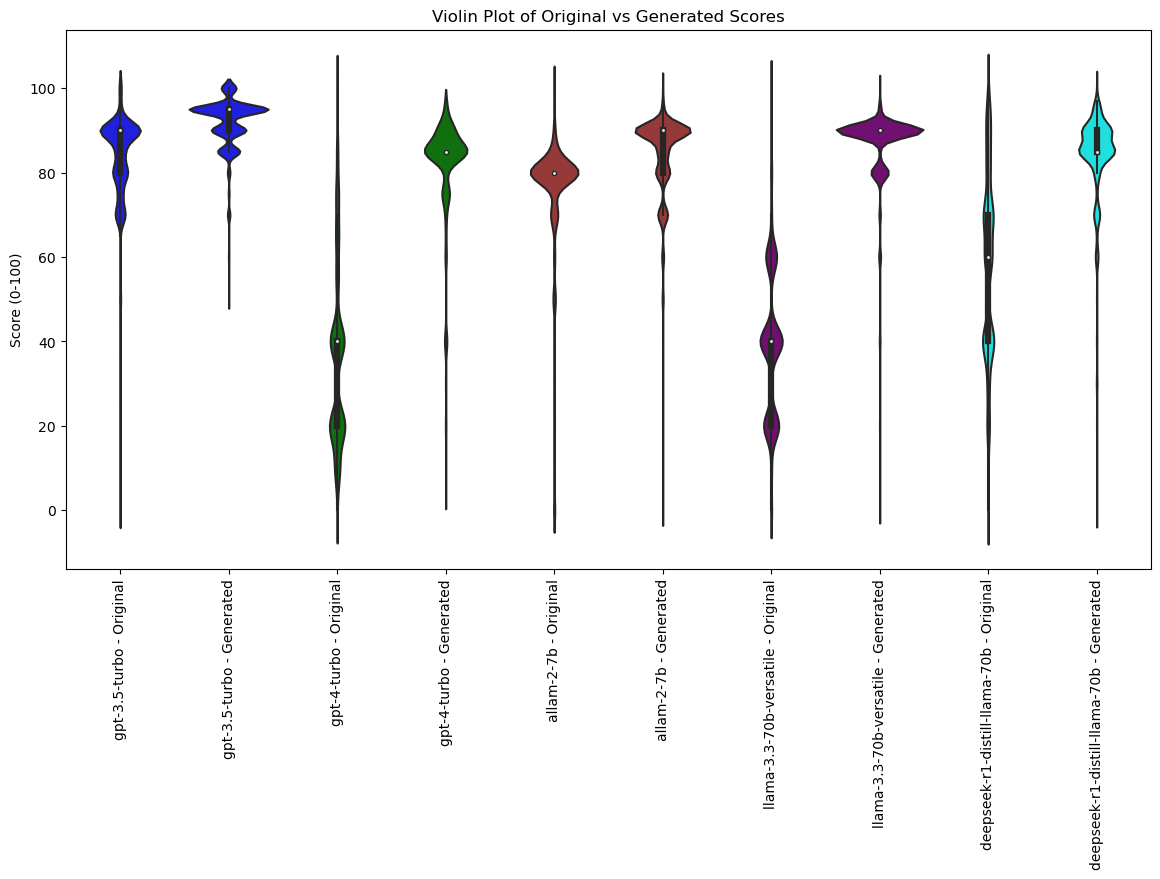

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define color palette: One color per model
model_colors = {
    "gpt-3.5-turbo": "blue",
    "gpt-4-turbo": "green",
    "allam-2-7b": "brown",
    "llama-3.3-70b-versatile": "purple",
    "deepseek-r1-distill-llama-70b": "cyan"
}

plt.figure(figsize=(14, 7))

# Prepare data and labels
data = []
labels = []
palette = []  # Store colors for better visualization

for model, df in evaluation_data.items():
    data.append(df["original_reason_score"])
    labels.append(f"{model} - Original")
    palette.append(model_colors[model])  # Assign color

    data.append(df["generated_reason_score"])
    labels.append(f"{model} - Generated")
    palette.append(model_colors[model])  # Keep the same color

# Create the violin plot with assigned colors
sns.violinplot(data=data, palette=palette)

plt.xticks(range(len(labels)), labels, rotation=90)
plt.ylabel("Score (0-100)")
plt.title("Violin Plot of Original vs Generated Scores")

plt.show()


# Scatter Plot - Original vs. Generated Scores

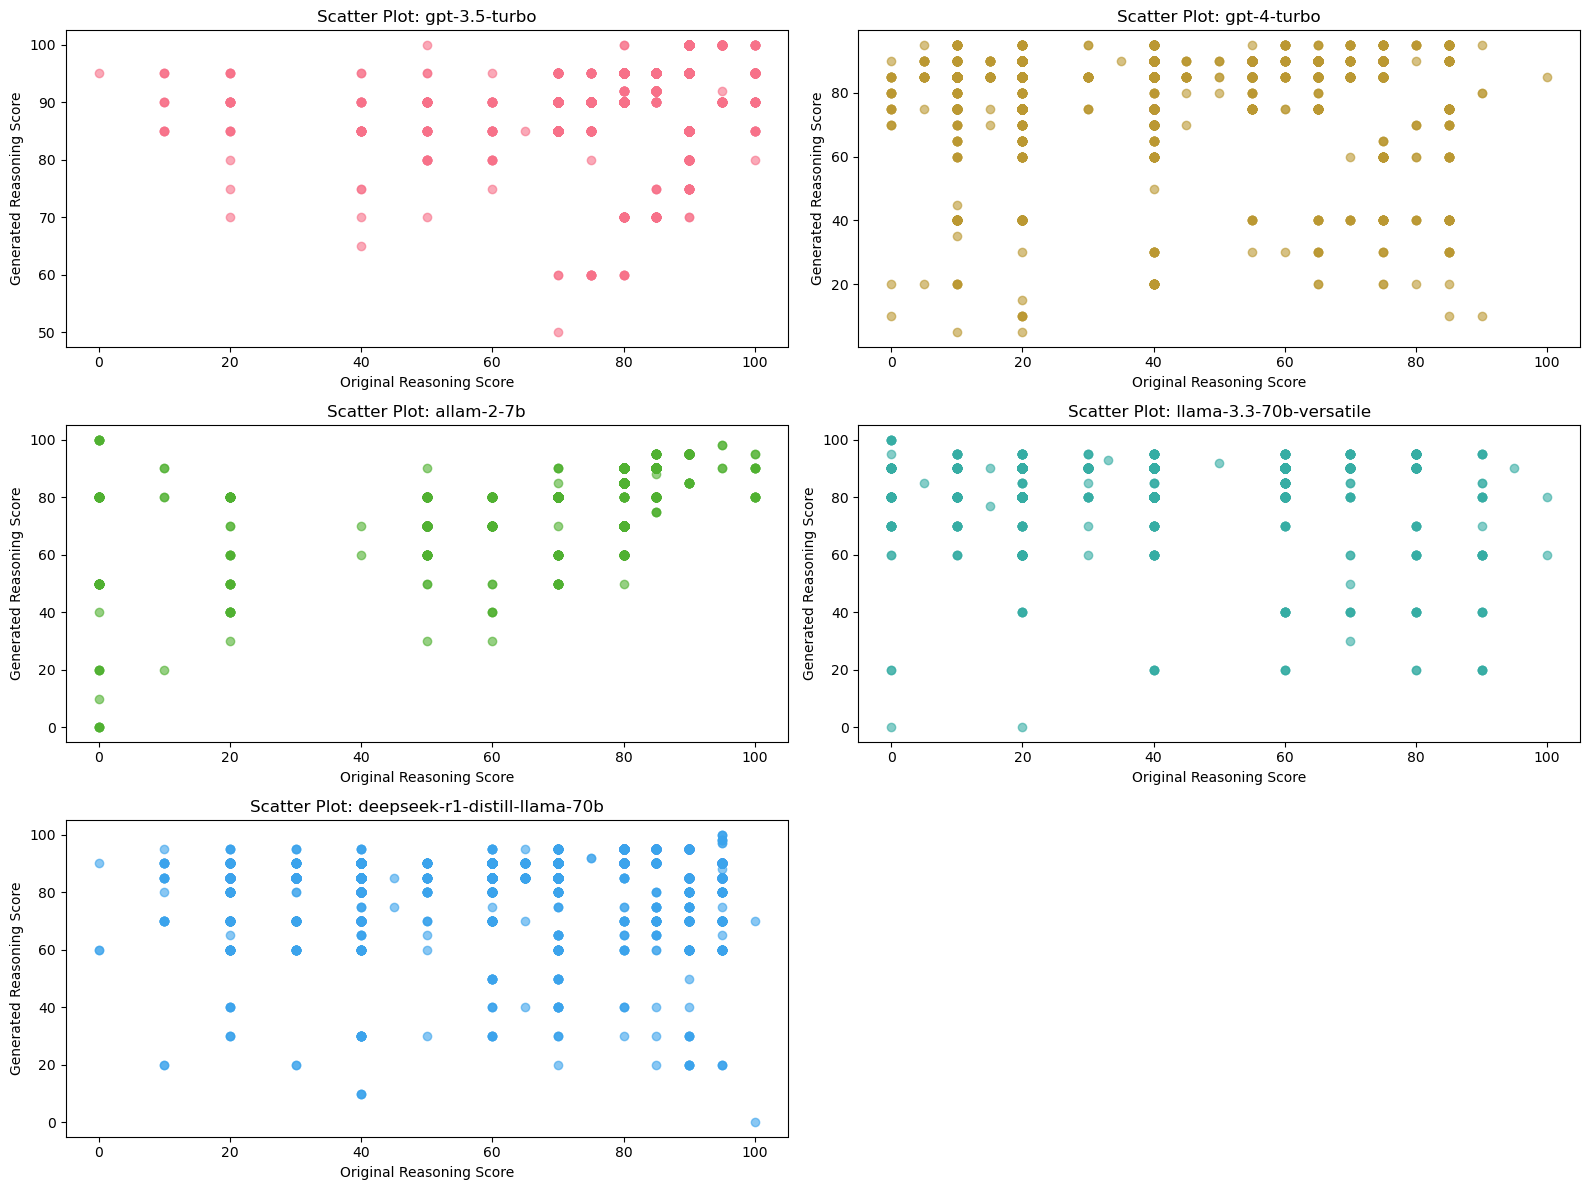

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define figure size
plt.figure(figsize=(16, 12))

# Loop through each model and create individual scatter plots
for i, (model, df) in enumerate(evaluation_data.items(), 1):
    plt.subplot(3, 2, i)  # Create a 3-row, 2-column subplot layout
    plt.scatter(df["original_reason_score"], df["generated_reason_score"], alpha=0.6, color=sns.color_palette("husl")[i-1])
    
    plt.xlabel("Original Reasoning Score")
    plt.ylabel("Generated Reasoning Score")
    plt.title(f"Scatter Plot: {model}")

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()


# Heatmap of Score Differences

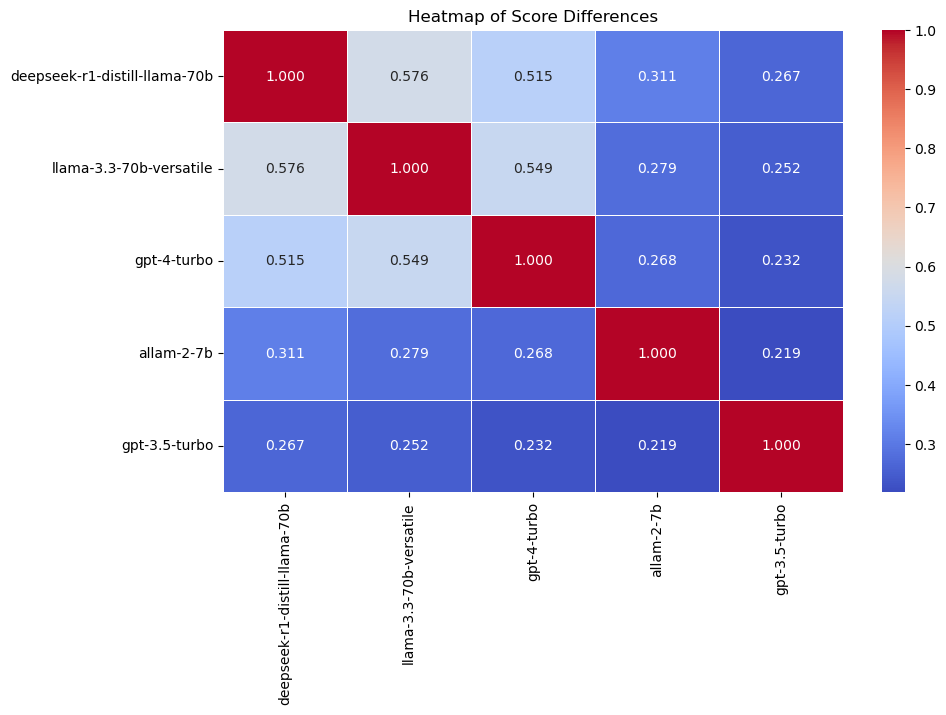

In [30]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

score_diffs = {model: evaluation_data[model]["generated_reason_score"] - evaluation_data[model]["original_reason_score"]
               for model in evaluation_data}

diff_df = pd.DataFrame(score_diffs)

# Compute correlation matrix
corr_matrix = diff_df.corr()

# Sort by correlation strength
sorted_models = corr_matrix.mean().sort_values(ascending=False).index
corr_matrix = corr_matrix.loc[sorted_models, sorted_models]

# Heatmap with better formatting
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5)
plt.title("Heatmap of Score Differences")
plt.show()


# Bar Chart - Average Scores Comparison

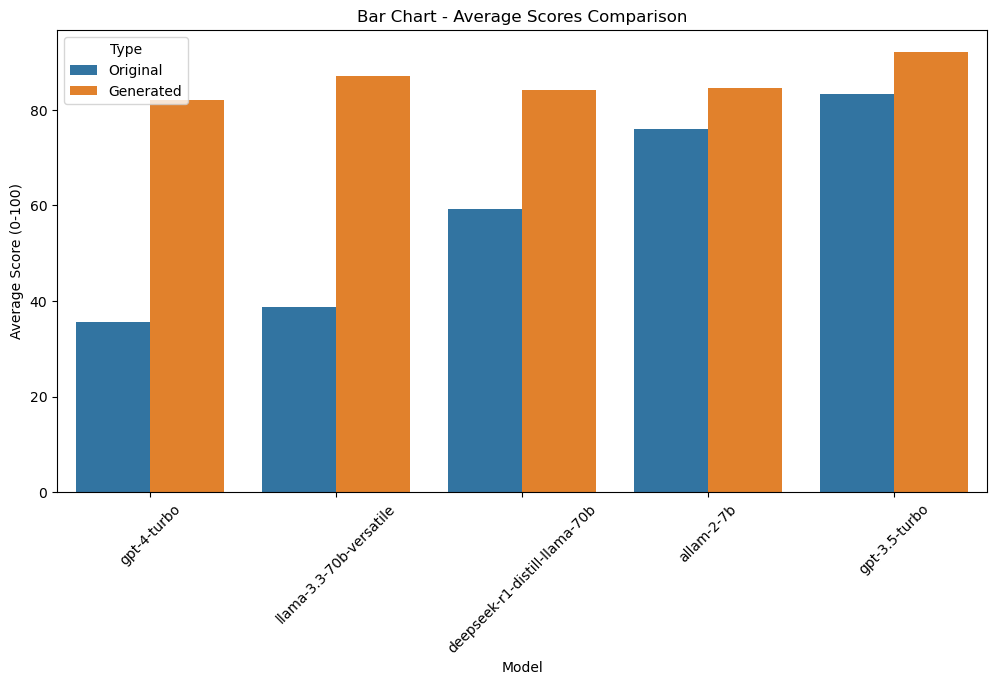

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute average scores and percentage improvement
avg_scores = []
improvement_data = []

for model, df in evaluation_data.items():
    original_avg = df["original_reason_score"].mean()
    generated_avg = df["generated_reason_score"].mean()
    improvement = ((generated_avg - original_avg) / original_avg) * 100

    avg_scores.append([model, "Original", original_avg])
    avg_scores.append([model, "Generated", generated_avg])
    improvement_data.append([model, improvement])

# Convert to DataFrames
avg_df = pd.DataFrame(avg_scores, columns=["Model", "Type", "Average Score"])
improvement_df = pd.DataFrame(improvement_data, columns=["Model", "Improvement %"])

# Sort by improvement
avg_df["Model"] = pd.Categorical(avg_df["Model"], categories=improvement_df.sort_values("Improvement %", ascending=False)["Model"], ordered=True)

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Average Score", hue="Type", data=avg_df)
plt.ylabel("Average Score (0-100)")
plt.title("Bar Chart - Average Scores Comparison")
plt.xticks(rotation=45)
plt.show()


# Comparative Model Performance

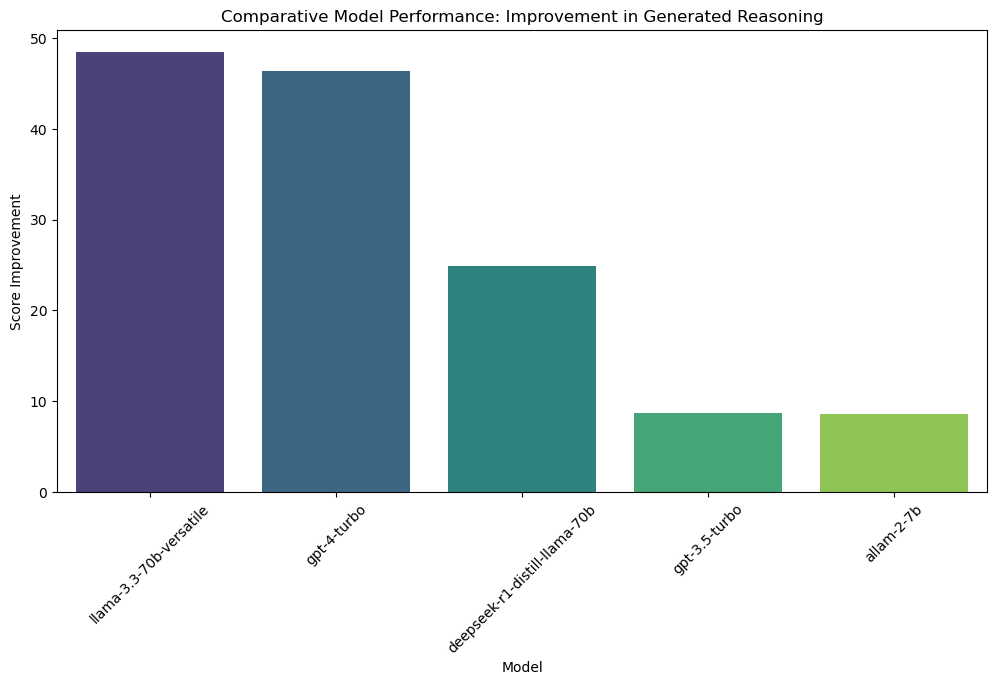

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate model performance improvement
performance_data = {"Model": [], "Improvement": [], "Percentage Improvement": []}

for model, df in evaluation_data.items():
    avg_original = df["original_reason_score"].mean()
    avg_generated = df["generated_reason_score"].mean()
    improvement = avg_generated - avg_original
    percentage_improvement = ((avg_generated - avg_original) / avg_original) * 100  # Percentage improvement calculation

    performance_data["Model"].append(model)
    performance_data["Improvement"].append(improvement)
    performance_data["Percentage Improvement"].append(percentage_improvement)

performance_df = pd.DataFrame(performance_data)

# Sort data by improvement
performance_df = performance_df.sort_values(by="Improvement", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Improvement", data=performance_df, palette="viridis")
plt.ylabel("Score Improvement")
plt.title("Comparative Model Performance: Improvement in Generated Reasoning")
plt.xticks(rotation=45)
plt.show()


# Failure Rate Analysis

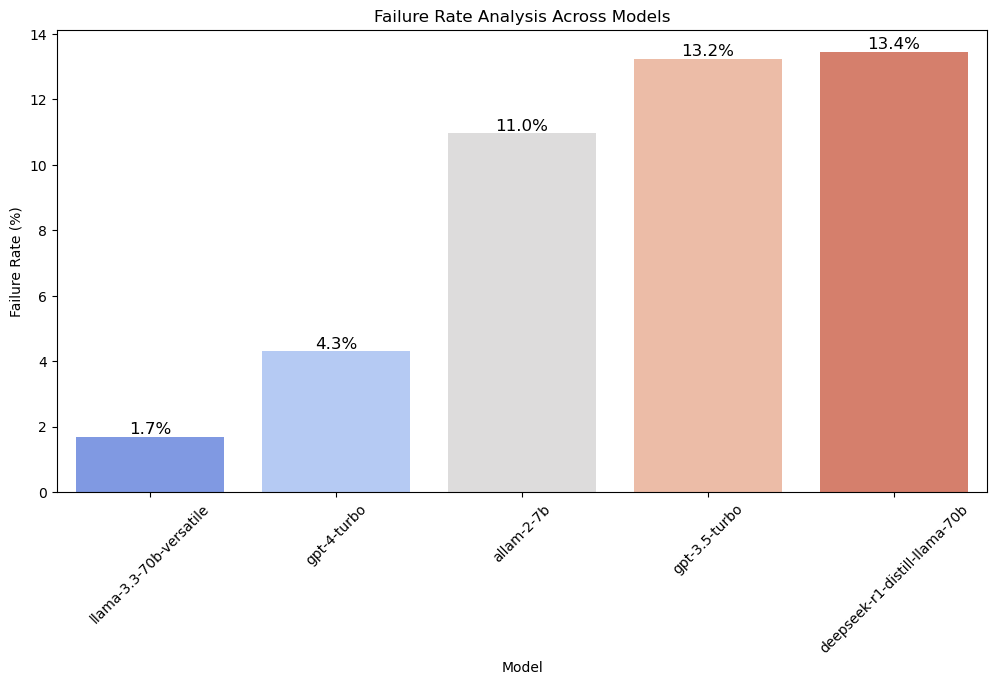

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Compute failure rates
failure_rates = []
for model, df in evaluation_data.items():
    failure_rate = (df["generated_reason_score"] < df["original_reason_score"]).sum() / len(df) * 100
    failure_rates.append([model, failure_rate])

# Convert to DataFrame
failure_df = pd.DataFrame(failure_rates, columns=["Model", "Failure Rate"])

# Sort models by failure rate
failure_df = failure_df.sort_values(by="Failure Rate", ascending=True)

# Create bar chart
ax = sns.barplot(x="Model", y="Failure Rate", data=failure_df, palette="coolwarm")
plt.ylabel("Failure Rate (%)")
plt.title("Failure Rate Analysis Across Models")

# Add percentage labels
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)

plt.xticks(rotation=45)
plt.show()


# Percentage Improvement Boxplot

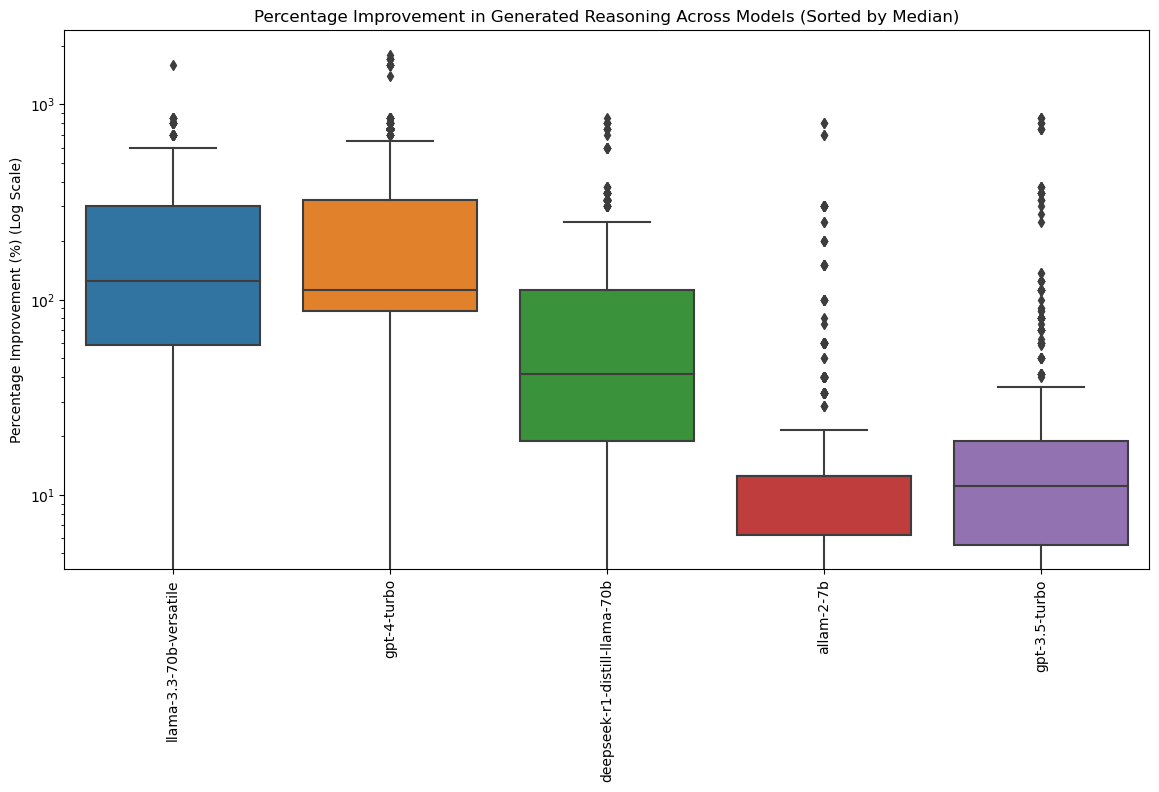

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 7))

percentage_improvements = []
labels = []

for model, df in evaluation_data.items():
    improvement = ((df["generated_reason_score"] - df["original_reason_score"]) / df["original_reason_score"]) * 100
    percentage_improvements.append(improvement)
    labels.append(model)

# Convert to DataFrame
improvement_df = pd.DataFrame(percentage_improvements).T
improvement_df.columns = labels

# Sort by median improvement
sorted_models = improvement_df.median().sort_values(ascending=False).index
improvement_df = improvement_df[sorted_models]

# Create the boxplot with log scale
sns.boxplot(data=improvement_df)
plt.yscale("log")  # Use logarithmic scale for better visualization
plt.xticks(rotation=90)
plt.ylabel("Percentage Improvement (%) (Log Scale)")
plt.title("Percentage Improvement in Generated Reasoning Across Models (Sorted by Median)")
plt.show()
